# Day-Ahead Price Utility — Example Notebook

This notebook demonstrates the public API from `utils/prices_utils.py`.

| Function | What it does |
|---|---|
| `get_daily_prices(target_date=None, mode="auto", secrets_dir="secrets", allow_fallback=True)` | Returns one strict UTC day of day-ahead prices in 15-minute resolution |

**Returned columns**
- `time` — UTC timestamp
- `price_eur_mwh` — price in EUR/MWh
- `price_cent_kwh` — price in ct/kWh
- `source` — `entsoe_api`, `not_published`, or `fallback_unavailable`
- `note` — optional explanation for fallback paths

## What These API Prices Mean

The values come from the ENTSOE day-ahead market for the `DE_LU` bidding zone.

- They are **wholesale electricity market prices**, not a final residential tariff.
- They are quoted in **EUR/MWh** by the market and converted here to **ct/kWh**.
- They usually represent the result of the **day-ahead auction** for delivery on the requested date.
- They do **not** include grid fees, taxes, supplier margin, or other retail markups.
- ENTSOE market data is usually published in market time (`Europe/Berlin`), but this utility normalizes everything to a strict **UTC** day.

> Run from project root or use the path bootstrap cell below.

In [1]:
import sys
from pathlib import Path
from datetime import date, timedelta

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.prices_utils import get_daily_prices

print(f"Project root: {root}")

# Default call: tomorrow in UTC
tomorrow_prices = get_daily_prices()

print(f"Rows   : {len(tomorrow_prices)}")
print(f"Source : {tomorrow_prices['source'].iloc[0]}")
print(f"Columns: {list(tomorrow_prices.columns)}")
print()
tomorrow_prices.head(8)

Project root: /Users/joscham/dsai/repos/hems-automation


/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)
/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)


Rows   : 96
Source : not_published
Columns: ['time', 'price_eur_mwh', 'price_cent_kwh', 'source', 'note']



/var/folders/q0/yjjd72s14db5phz6__48py4w0000gn/T/ipykernel_12979/2924413101.py:19: UserWarning: Day-ahead prices for 2026-03-24 have not been published yet. ENTSOE typically publishes D+1 prices around 13:00 CET.
  tomorrow_prices = get_daily_prices()


,time,price_eur_mwh,price_cent_kwh,source,note
0,2026-03-24 00:00:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
1,2026-03-24 00:15:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
2,2026-03-24 00:30:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
3,2026-03-24 00:45:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
4,2026-03-24 01:00:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
5,2026-03-24 01:15:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
6,2026-03-24 01:30:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...
7,2026-03-24 01:45:00+00:00,NaN,NaN,not_published,Day-ahead prices for this day have not been pu...


In [2]:
# Explicit historical day
historical_prices = get_daily_prices(target_date="2025-01-15", mode="historical")
print(f"Historical source: {historical_prices['source'].iloc[0]}")
print()
historical_prices.head(8)

# Explicit future day
future_date = (date.today() + timedelta(days=3)).isoformat()
future_prices = get_daily_prices(target_date=future_date)
print(f"Future target: {future_date}")
print(f"Future source: {future_prices['source'].iloc[0]}")

/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)


Historical source: entsoe_api



/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)
/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)


Future target: 2026-03-26
Future source: not_published


/var/folders/q0/yjjd72s14db5phz6__48py4w0000gn/T/ipykernel_12979/2444358702.py:9: UserWarning: Day-ahead prices for 2026-03-26 have not been published yet. ENTSOE typically publishes D+1 prices around 13:00 CET.
  future_prices = get_daily_prices(target_date=future_date)


## Output behavior and fallback modes

`get_daily_prices()` always returns a **96-row UTC day**.

Possible `source` values:
- `entsoe_api` — live ENTSOE result
- `not_published` — the day-ahead auction for that day is not published yet
- `fallback_unavailable` — the API request failed and a NaN frame was returned

### Additional API notes

- Day-ahead prices for **tomorrow** are typically published around **13:00 CET/CEST**.
- Recent ENTSOE data may be available in **15-minute** market resolution, while older dates can be **hourly**.
- `prices_utils.py` handles that internally by trying 15-minute data first and falling back to hourly data when needed.
- If hourly data is returned by the API, the utility expands it to 15-minute slots so the final output shape stays consistent.
- The final frame always covers **00:00:00 to 23:45:00 UTC** for the requested day.

If a fallback path is used, the returned DataFrame may include a `note` column with more detail.

In [3]:
df = historical_prices.copy()

print("Shape:", df.shape)
print()
print("dtypes:")
print(df.dtypes)
print()
df.describe(include="all")

Shape: (96, 4)

dtypes:
time              datetime64[ns, UTC]
price_eur_mwh                 float64
price_cent_kwh                float64
source                         object
dtype: object



,time,price_eur_mwh,price_cent_kwh,source
count,96,96.000000,96.000000,96
unique,NaN,NaN,NaN,1
top,NaN,NaN,NaN,entsoe_api
freq,NaN,NaN,NaN,96
mean,2025-01-15 11:52:30+00:00,222.933333,22.293333,NaN
min,2025-01-15 00:00:00+00:00,107.720000,10.772000,NaN
25%,2025-01-15 05:56:15+00:00,125.722500,12.572250,NaN
50%,2025-01-15 11:52:30+00:00,230.940000,23.094000,NaN
75%,2025-01-15 17:48:45+00:00,309.760000,30.976000,NaN
max,2025-01-15 23:45:00+00:00,377.990000,37.799000,NaN


/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)
/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)


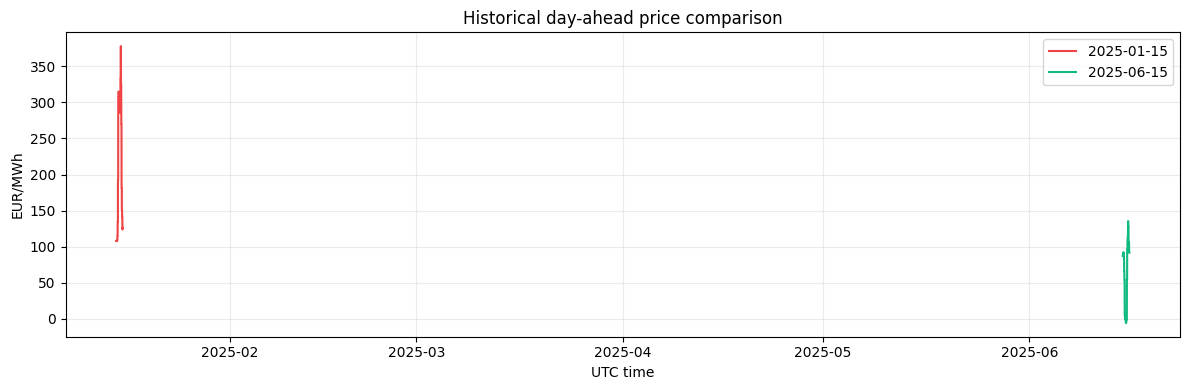

In [4]:
winter_prices = get_daily_prices(target_date="2025-01-15", mode="historical")
summer_prices = get_daily_prices(target_date="2025-06-15", mode="historical")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(winter_prices["time"], winter_prices["price_eur_mwh"], label="2025-01-15", color="#ef4444")
ax.plot(summer_prices["time"], summer_prices["price_eur_mwh"], label="2025-06-15", color="#10b981")
ax.set_title("Historical day-ahead price comparison")
ax.set_xlabel("UTC time")
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

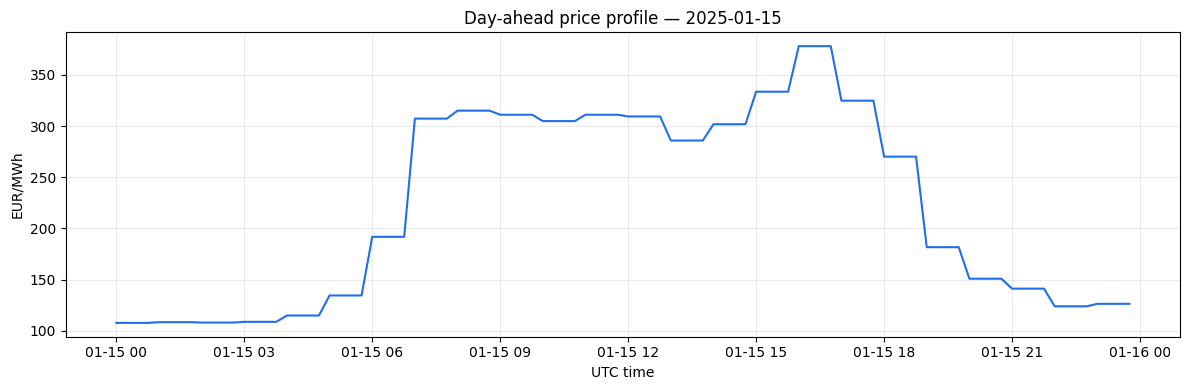

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["time"], df["price_eur_mwh"], color="#1f6feb", linewidth=1.5)
ax.set_title(f"Day-ahead price profile — {df['time'].dt.date.iloc[0]}")
ax.set_xlabel("UTC time")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [6]:
valid_prices = df["price_eur_mwh"].dropna()

print(f"Min EUR/MWh : {valid_prices.min():.2f}" if not valid_prices.empty else "Min EUR/MWh : NaN")
print(f"Max EUR/MWh : {valid_prices.max():.2f}" if not valid_prices.empty else "Max EUR/MWh : NaN")
print(f"Mean EUR/MWh: {valid_prices.mean():.2f}" if not valid_prices.empty else "Mean EUR/MWh: NaN")
print(f"Missing rows: {df['price_eur_mwh'].isna().sum()} of {len(df)}")
print(f"Unique source values: {df['source'].unique().tolist()}")

if "note" in df.columns:
    print()
    print("Notes:")
    print(df["note"].dropna().unique().tolist())

Min EUR/MWh : 107.72
Max EUR/MWh : 377.99
Mean EUR/MWh: 222.93
Missing rows: 0 of 96
Unique source values: ['entsoe_api']
